# Fairness : Mi-Projet

*Travail réalisé par Cyprien BRION - L3 Informatique*

## Introduction

L'essor des méthodes d'apprentissage automatique dans le domaine médical soulève des enjeux majeurs en matière d'équité et de biais algorithmiques. En effet, les modèles entraînés sur des données de santé peuvent reproduire, voire amplifier, des biais présents dans les jeux de données d'origine, liés par exemple à l'âge, au genre ou à d'autres caractéristiques démographiques des patients. Ces biais peuvent donc conduire à des performances inégales selon les populations et poser de nombreux problèmes éthiques.

Dans ce mi-projet, nous nous intéresserons au jeu de données NIH Chest X-ray 14, qui regroupe des examens de radiographies thoraciques accompagnés de métadonnées décrivant les patients. Dans un premier temps, nous nous concentrerons exclusivement sur ces métadonnées, sans exploiter les images, afin d'analyser la structure du jeu de données et d'identifier d'éventuels biais statistiques.

Dans ce notebook, nous réaliserons une analyse descriptive approfondie des métadonnées afin de mettre en évidence des biais potentiels entre différents groupes d'individus. Ensuite, nous réaliserons une méthode de mitigation des biais par pré-processing visant à atténuer ces biais, tout en conservant autant que possible l'information utile contenue dans les données.

## I. Préparation de la donnée

### a. Chargement de données et aperçu des données

Commençons par charger notre jeu de données :

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Pour le chargement du jeu de données
df = pd.read_csv("Brion_Cyprien.csv")
df.head()


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
1,00000004_000.png,Mass|Nodule,0,4,82,M,AP,2500,2048,0.168,0.168
2,00000005_000.png,No Finding,0,5,69,F,PA,2048,2500,0.168,0.168
3,00000005_001.png,No Finding,1,5,69,F,AP,2500,2048,0.168,0.168
4,00000005_002.png,No Finding,2,5,69,F,AP,2500,2048,0.168,0.168


Ensuite, observons plus en détail les caractéristiques de ce jeu de données :

In [3]:
df.shape

(53951, 11)

Analysons désormais le type des variables contenues dans ce dataset :

In [4]:
df.dtypes

Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
dtype: object

### b. Vérifications et nettoyage du jeu de données

Vérifions désormais la présence de valeurs manquantes dans le jeu de données.

In [5]:
df.isna().sum()

Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
dtype: int64

On observe qu'aucune des variables du jeu de données ne contient de valeurs manquantes.

Regardons désormais si notre jeu de données contient des valeurs aberrantes. Bien sûr, cela ne concerne que les variables numériques.

In [6]:
df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,53951.000000,53951.000000,53951.000000,53951.000000,53951.000000,53951.000000,53951.000000
mean,8.432263,14409.935367,46.937054,2645.894163,2488.074790,0.155670,0.155670
std,15.228100,8371.393985,16.712377,341.299413,402.836045,0.016239,0.016239
min,0.000000,2.000000,1.000000,1143.000000,1001.000000,0.115000,0.115000
25%,0.000000,7526.000000,35.000000,2500.000000,2048.000000,0.143000,0.143000
50%,3.000000,14006.000000,49.000000,2520.000000,2544.000000,0.143000,0.143000
75%,9.000000,20725.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000
max,172.000000,30805.000000,413.000000,3550.000000,4715.000000,0.198800,0.198800


On remarque ici qu'il y a des valeurs aberrantes pour la colonne `Patient Age`. En effet, le maximum pour cette colonne est de 413, ce qui signifierait qu'un patient à 413 ans, ce qui n'est clairement pas réaliste.

Pour corriger ce problème, nous allons filtrer les valeurs de la colonne `Patient Age` selon un intervalle réaliste : 

In [10]:
df = df[(df["Patient Age"] >= 0) & (df["Patient Age"] <= 120)]
df["Patient Age"].describe()

count    53942.000000
mean        46.900467
std         16.385627
min          1.000000
25%         35.000000
50%         49.000000
75%         59.000000
max         94.000000
Name: Patient Age, dtype: float64

Après nettoyage, les valeurs sont désormais bien plus réalistes.

Effectuons une analyse pour observer le nombre de valeurs distinctes par variable afin de confirmer qu'il n'y aurait pas de valeurs manquantes encodées de manière implicite.

In [11]:
df.nunique()

Image Index                    53942
Finding Labels                   627
Follow-up #                      173
Patient ID                     15000
Patient Age                       94
Patient Gender                     2
View Position                      2
OriginalImage[Width              756
Height]                          912
OriginalImagePixelSpacing[x       21
y]                                21
dtype: int64

On remarque donc que le nombre de valeurs distinctes est cohérent avec l'énoncé. Aucune variable ne présente donc de valeurs manquantes qui auraient pu être encodées implicitement.
Néanmoins, à partir de ces résultats on peut noter que :
* Les variables `Patient Gender` et `View Position` ne possèdent que deux valeurs distinctes chacune, ce qui en fait des variables clés pour l'analyse des biais.

Pour finir, vérifions si des lignes ont été dupliquées :

In [12]:
dup_rows = df.duplicated().sum()
print(f"Doublons exacts (toutes colonnes) : {dup_rows}")

Doublons exacts (toutes colonnes) : 0


Il n'y a donc aucun doublon dans notre dataset.

Observons la distribution du nombre d'examens par patient afin de repérer les patients multi-examens :

In [14]:
exam_stats = df.groupby("Patient ID").size().describe()
print("Statistiques du nombre d'examens par patient :")
print(exam_stats)

Statistiques du nombre d'examens par patient :
count    15000.000000
mean         3.596133
std          7.163112
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        173.000000
dtype: float64


Ceci va nous permettre de répondre à la question suivante : les patients qui ont beaucoup d'examens sont-ils plus souvent malades ?

In [18]:
exam_counts = df.groupby("Patient ID").size()
exam_counts.describe()

count    15000.000000
mean         3.596133
std          7.163112
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        173.000000
dtype: float64

On découpe les patients selon leur nombre d'examens et on calcule pour chaque groupe, la proportion de patiens ayant au moins une pathologie avec `has_disease = True`

In [19]:
df = df.merge(
    exam_counts.rename("nb_exams"),
    left_on="Patient ID",
    right_index=True
)


In [37]:
df["has_disease"] = df["Finding Labels"] != "No Finding"

In [22]:
df.groupby(
    pd.cut(df["nb_exams"], bins=[0,1,3,10,200])
)["has_disease"].mean()


/tmp/ipykernel_12227/1971727585.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


nb_exams
(0, 1]       0.272535
(1, 3]       0.353521
(3, 10]      0.434452
(10, 200]    0.579562
Name: has_disease, dtype: float64

On observe une relation strictement croissante ce qui est plutôt logique. Les patients qui reviennent souvent sont beaucoup plus souvent malades. Le nombre d'examens est donc corrélé à l'état de santé.

**Remarque :** cette analyse n'est pas un biais du modèle mais cela pourra être problématique pour l'apprentissage du modèle. Nous n'irons pas plus loin pour cette analyse puisque l'apprentissage du modèle n'est pas demandé.

## II. Analyse descriptive et observation des biais

### a. Analyse univariée

#### 1. Genre (déséquilibre de représentation)

Commençons par observer la répartition des examens selon le genre :

In [24]:
gender_counts = df["Patient Gender"].value_counts()
gender_counts

Patient Gender
M    30332
F    23610
Name: count, dtype: int64

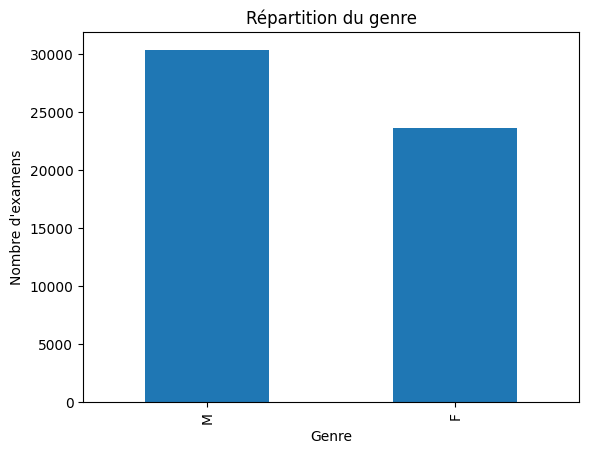

In [25]:
ax = gender_counts.plot(kind="bar")
ax.set_title("Répartition du genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Nombre d'examens")
plt.show()


La répartition des examens selon le genre montre un léger déséquilibre. En effet, les hommes sont légèrement plus représentés que les femmes.
On notera cependant que l'on devra compléter cette observation par une analyse au niveau du patient car un petit nombre de patients très suivis peuvent amplifier artificiellement ce dédéquilibre.
On regardera également dans la suite la prévalence des pathologies conditionnellement au genre.

#### 2. View Position (AP/PA)

Intéressons nous désormais à l'attribut `View Position`. En effet AP/PA peut refléter des conditions d'acquisition différentes. Cela peut donc être corrélé à la maladie.

In [26]:
view_counts = df["View Position"].value_counts()
view_counts

View Position
PA    32642
AP    21300
Name: count, dtype: int64

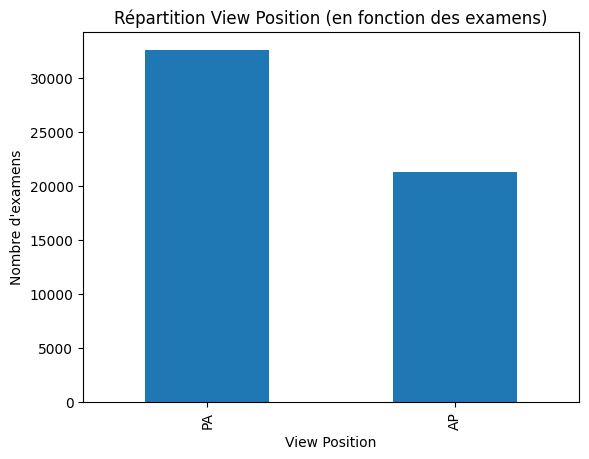

In [ ]:
ax = view_counts.plot(kind="bar")
ax.set_title("Répartition View Position (en fonction du nombre d'examens)")
ax.set_xlabel("View Position")
ax.set_ylabel("Nombre d'examens")
plt.show()


La répartition de la variable `View Position` montre un déséquilibre : les examens en position PA sont plus nombreux que ceux en position AP.
On notera que cette variable est particulièrement importante car AP et PA peuvent refléter des conditions d'acquisition différentes (patients debout vs allongés / urgence) et donc être corrélés à la présence de pathologies. Dans la suite, nous analyserons la prévalence des pathologies conditionnellement à `View Position` et nous quantifierons cet écart.

#### 3. Distribution globale de l'âge

Naturellement, l'âge est un facteur médical majeur : une surreprésentation des séniors (ou l'inverse) peut conduire à des distributions de maladies très différentes entre groupes.

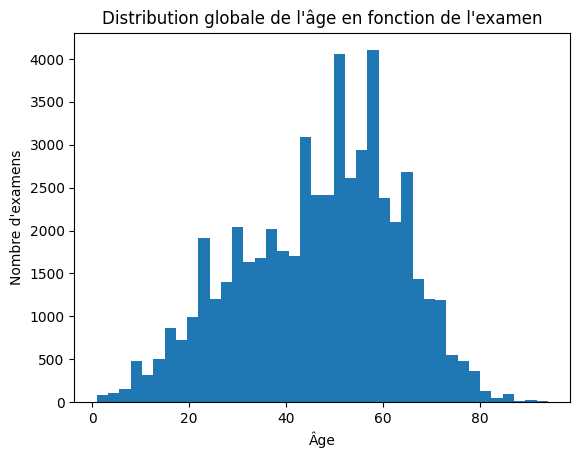

In [ ]:
plt.figure()
plt.hist(df["Patient Age"], bins=40)
plt.title("Distribution globale de l'âge en fonction du nombre d'examens")
plt.xlabel("Âge")
plt.ylabel("Nombre d'examens")
plt.show()


La distribution globale de l'âge paraît cohérente : la majorité des examens concernent des adultes, avec un pic autour de 50–60 ans, puis une décroissance pour les âges élevés. Les extrêmes d'âge ne sont que très peu représentés. Néanmoins ceci paraît plutôt normal puisque les pathologies thoraciques sont globalement plus fréquentes à certains âges. Il est donc logique que les adultes dans la tranche 50-60 ans soient plus représentés.

#### 4. Suivi médical par patient

Observons désormais la distribution du nombre d'examens par patient :

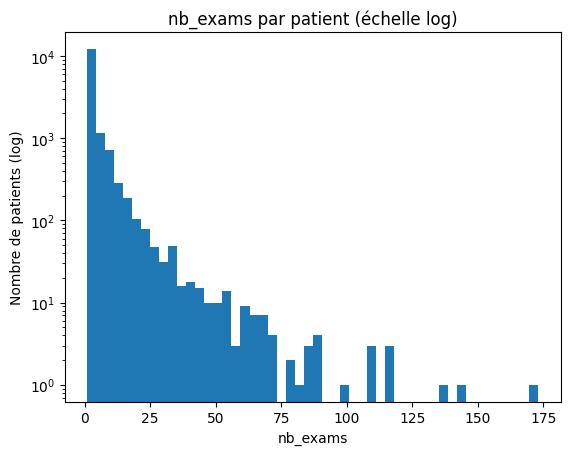

In [32]:
plt.figure()
plt.hist(exam_counts, bins=50, log=True)
plt.title("nb_exams par patient (échelle log)")
plt.xlabel("nb_exams")
plt.ylabel("Nombre de patients (log)")
plt.show()


On observe que la majorité des patients n’ont que très peu d’examens, tandis qu’une minorité possède un nombre très élevé d’examens (jusqu’à ~170).

#### 5. Prévalence globale "malade" v.s. "No Finding"

Nous évaluons désormais la prévalence globale des pathologies dans notre dataset en comparant
les examens “No Finding” aux examens présentant au moins une anomalie.

In [38]:
df["has_disease"].mean(), df["has_disease"].value_counts()


(np.float64(0.46197767973008047),
 has_disease
 False    29022
 True     24920
 Name: count, dtype: int64)

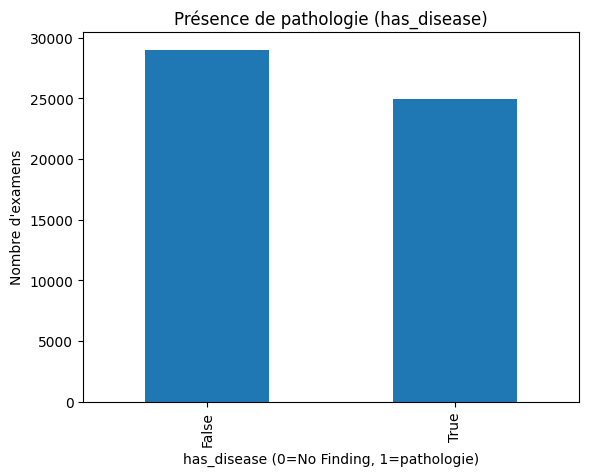

In [39]:
ax = df["has_disease"].value_counts().plot(kind="bar")
ax.set_title("Présence de pathologie (has_disease)")
ax.set_xlabel("has_disease (0=No Finding, 1=pathologie)")
ax.set_ylabel("Nombre d'examens")
plt.show()


La comparaison globale entre examens “No Finding” et examens présentant au moins une pathologie
montre un léger déséquilibre en faveur de “No Finding”. Cependant, l’écart reste modéré et la
répartition est relativement proche d’un équilibre entre les deux classes.

In [40]:
df["has_disease"].mean()

np.float64(0.46197767973008047)

La prévalence globale (i.e. la proportion d’examens dans le dataset qui sont classés “malade” (c'est à dire `has_disease = 1`), sur l’ensemble du dataset est donc ici d'environ 46%.

#### 6. Analyse multi-label : les top-pathologies (hors No Finding)

`Finding Labels` étant une variable multi-label, certaines combinaisons et pathologies rares peuvent être peu représentées lors des examens. C'est ce que l'on va tenter d'observer ici :

In [42]:
labels = df["Finding Labels"].str.split("|").explode()
labels = labels[labels != "No Finding"]
top10 = labels.value_counts().head(10)
top10

Finding Labels
Infiltration          9568
Effusion              6269
Atelectasis           5586
Nodule                3188
Mass                  2910
Pneumothorax          2342
Consolidation         2214
Pleural_Thickening    1635
Cardiomegaly          1397
Emphysema             1214
Name: count, dtype: int64

On trace un graphe pour mieux visualiser :

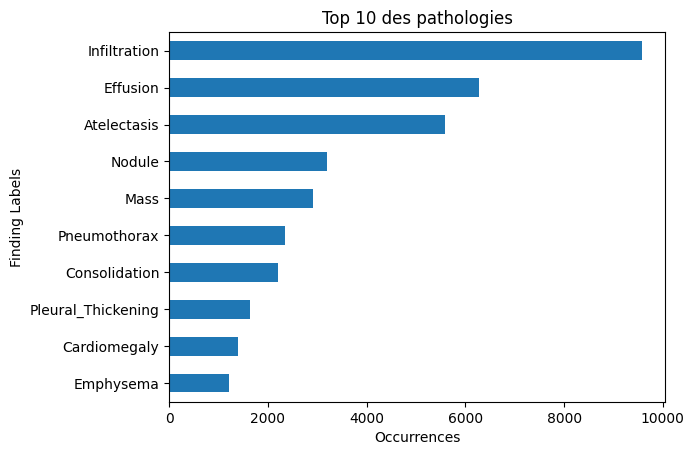

In [44]:
ax = top10.sort_values().plot(kind="barh")
ax.set_title("Top 10 des pathologies")
ax.set_xlabel("Occurrences")
plt.show()


**Remarque :** une image peut compter plusieurs occurences (si plusieurs labels) donc ici le graphe décrit une prévalence des labels par examens, pas par patient.

Ceci paraît cohérent médicalement parlant, malgré une présence majoritaire de certains labels (notamment `Infiltration` et `Effusion`). En effet, certaines anomalies sont plus communes dans les radios thoraciques que d'autres.

### b. Analyse bivariée (biais / dépendances)